## 03. Model and Hyperparameter Tuning

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[0]))

In [2]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from src import tuning
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/sms_data_cleaned.csv')
df.sample(10)

,date,year,month,punctuation_count,word_count,text_count,carrier_Smart,carrier_Globe,carrier_DITO,carrier_Unknown,dedup_group_id,text_transformed,target
221,2024-05-13 07:36:52.520,2024,May,9,16,105,1,0,0,0,195,kumusta real name sumali cott free agad mag cl...,1
987,2019-06-04 05:54:24.715,2019,June,9,20,112,1,0,0,0,870,moneytoken waiting apply app meet guarantee vi...,0
437,2024-03-12 11:46:57.329,2024,March,2,10,56,1,0,0,0,379,tara manalo moneytoken gawin nating moneytoken...,2
511,2024-02-22 15:44:44.953,2024,February,6,16,100,1,0,0,0,443,imagine pesos could turn moneytoken play gold ...,1
339,2024-04-01 10:16:13.839,2024,April,4,7,66,0,1,0,0,299,magparehistro libreng moneytoken tumaya luck a...,0
589,2024-01-25 05:38:48.067,2024,January,6,18,122,1,0,0,0,515,banco de oro issues account security please re...,0
843,2023-04-04 22:00:32.034,2023,April,8,18,105,1,0,0,0,734,real name sign urltoken today claim streak sig...,2
532,2024-02-17 04:04:44.431,2024,February,3,39,198,0,0,0,1,464,link chosen bdo account card bdo pay app disco...,2
738,2023-09-07 00:24:56.097,2023,September,10,20,132,1,0,0,0,646,real name sugarplay welcome bonus hanggang dep...,2
670,2023-11-19 18:14:26.025,2023,November,12,28,204,1,0,0,0,588,dear banco de oro bank customer account verifi...,1


### Tuning

In [3]:
# subset the data
X = df['text_transformed']
y = df['target']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(sgkf.split(X, y, groups=df['dedup_group_id']))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print(f"Training Data Size: {len(train_df)} | Testing Data Size: {len(test_df)}")

y_train = train_df['target']
y_test = test_df['target']

X_train = train_df['text_transformed']
X_test = test_df['text_transformed']

Training Data Size: 817 | Testing Data Size: 204


## Tuned Naive Bayes (MultinomialNB)

In [4]:
nb_grid = {
    'clf__alpha' : [0.01, 0.1, 0.5, 1.0, 2.0],
    'clf__fit_prior' : [True, False]
}

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
    ('clf', MultinomialNB())
])

nb = tuning.tune_search(X_train, y_train, train_df['dedup_group_id'], pipeline, nb_grid)
nb_pred = nb.predict(X_test)
nb_prob = nb.predict_proba(X_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Model Best Parameters: {'clf__alpha': 0.5, 'clf__fit_prior': False}
Best CV macro F1: 0.7145300456773762


In [5]:
tuning.show_metrics(y_test, nb_pred, nb_prob)

=== Classifier Metrics ===
ROC AUC Score: 0.89029
Accuracy Score: 0.74510

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73        54
           1       0.76      0.78      0.77        82
           2       0.70      0.75      0.72        68

    accuracy                           0.75       204
   macro avg       0.75      0.74      0.74       204
weighted avg       0.75      0.75      0.75       204



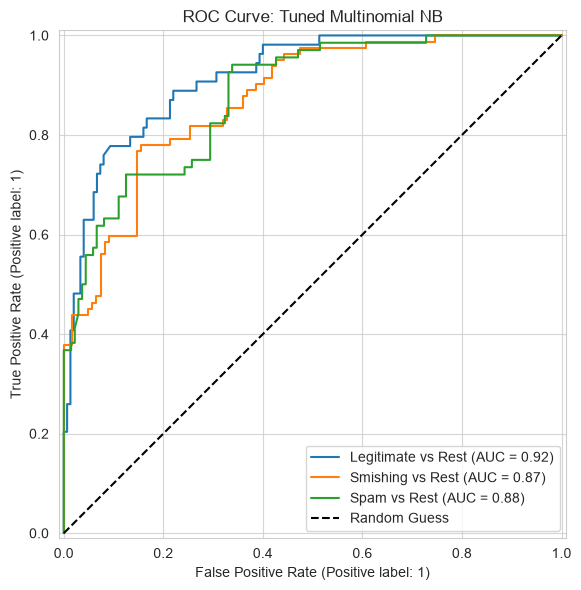

In [6]:
tuning.plot_curve(nb, X_test, y_test, 'Tuned Multinomial NB')

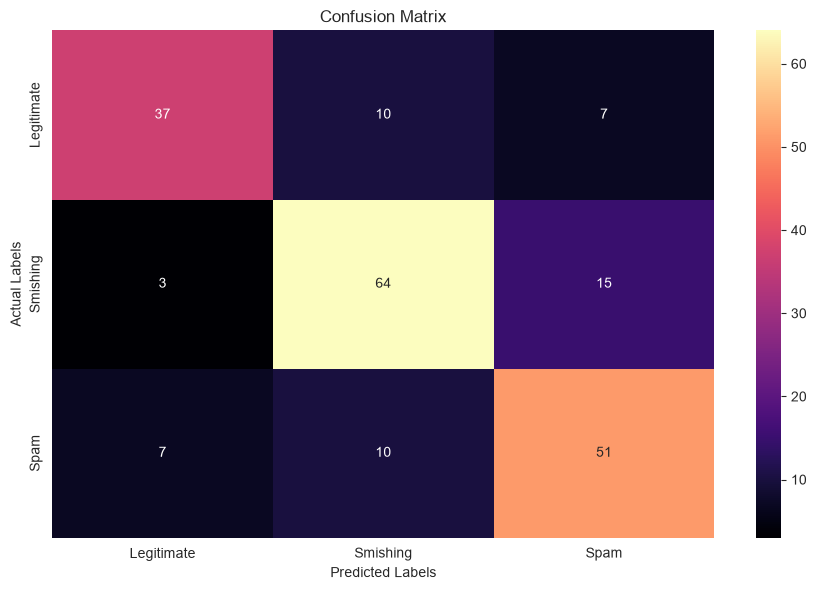

In [7]:
tuning.plot_matrix(y_test, nb_pred)

## Tuned Random Forests Clfs

In [ ]:
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
    ('clf', RandomForestClassifier())
])

rf_grid = {
    'clf__n_estimators': [200, 400, 600],
    'clf__max_depth': [None, 20, 40, 60],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': [None, 'balanced']
}

rf = tuning.tune_search(X_train, y_train, train_df['dedup_group_id'], pipeline, rf_grid)
rf_pred = rf.predicxt(X_test)
rf_prob = rf.predict_proba(X_test)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Model Best Parameters: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
Best CV macro F1: 0.7339042388836624


In [9]:
tuning.show_metrics(y_test, rf_pred, rf_prob)

=== Classifier Metrics ===
ROC AUC Score: 0.91030
Accuracy Score: 0.80882

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.85      0.77        54
           1       0.86      0.87      0.86        82
           2       0.86      0.71      0.77        68

    accuracy                           0.81       204
   macro avg       0.81      0.81      0.80       204
weighted avg       0.82      0.81      0.81       204

